In [ ]:
import casacore.tables as tbl
import numpy as np
import matplotlib.pyplot as plt
import pyuvdata
import sys

<module 'pyuvdata' from '/opt/devel/rbyrne/envs/py311/lib/python3.11/site-packages/pyuvdata/__init__.py'>

In [ ]:
# Choose one antenna and frequency to inspect
use_antenna_name = "LWA269"
use_freq = 37324218.75

In [ ]:
caltable_path = "/lustre/pipeline/calibration/results/2026-01-12/05h/successful/20260115_130732/tables/calibration_2026-01-12_05h.B.flagged"
data_path = "/fast/rbyrne/test_applycal_Mar2026/data_rewritten_orig_cal.ms"
data_single_chan_path = "/fast/rbyrne/test_applycal_Mar2026/data_single_chan_cal1.ms"

In [ ]:
uv_orig = pyuvdata.UVData()
uv_orig.read(
    data_path,
    data_column="DATA",
)
uv_orig.select(
    antenna_names=[use_antenna_name],
    polarizations=[-5],
    frequencies=[use_freq],
)  # Select one antenna, polarization, and frequency
uv_orig.write_ms(data_single_chan_path, clobber=True)

In [29]:
# In CASA, run:
# applycal("/fast/rbyrne/test_applycal_Mar2026/data_single_chan_cal1.ms", gaintable="/lustre/pipeline/calibration/results/2026-01-12/05h/successful/20260115_130732/tables/calibration_2026-01-12_05h.B.flagged",applymode="calflagstrict",interp="nearest,nearest",flagbackup=False)

In [ ]:
# Read CASA-calibrated data
casa_calibrated = pyuvdata.UVData()
casa_calibrated.read(
    data_single_chan_path,
    data_column="CORRECTED_DATA",
    ignore_single_chan=False,
)
uncalib = pyuvdata.UVData()
uncalib.read(
    data_single_chan_path,
    data_column="DATA",
    ignore_single_chan=False,
)

Fixing auto-correlations to be be real-only, after some imaginary values were detected in data_array. Largest imaginary component was 1.0, largest imaginary/real ratio was 1.4514072610438689e-08.


In [7]:
print(np.sqrt(uncalib.data_array / casa_calibrated.data_array))  # Gain, inferred by comparing raw and calibrated autocorrelation visibility for the chosen antenna

[[[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]

 [[0.00046787+0.j]]]


In [12]:
casa_gain = np.nanmean(np.abs(np.sqrt(uncalib.data_array / casa_calibrated.data_array)))
print(casa_gain)

0.00046786704


In [ ]:
# Read caltable with pyuvdata
cal = pyuvdata.UVCal()
cal.read(caltable_path)
cal.select(
    antenna_names=[use_antenna_name],
    jones=[-5],
    frequencies=[use_freq],
)
cal.gain_array[np.where(cal.flag_array)] = np.nan + 1j*np.nan
print(cal.gain_array)

Setting telescope_location to value in known_telescopes for OVRO-LWA.
Unknown polarization basis for solutions, jones_array values may be spurious.


[[[[        nan       +nanj]
   [        nan       +nanj]
   [        nan       +nanj]
   [-0.00171063-0.00215323j]
   [        nan       +nanj]
   [        nan       +nanj]
   [        nan       +nanj]
   [        nan       +nanj]]]]


Unknown x_orientation basis for solutions, assuming "east".


In [10]:
pyuvdata_gain = np.nanmean(np.abs(cal.gain_array))
print(pyuvdata_gain)

0.002750022194640909


In [ ]:
# Now let's read the caltable directly:
with tbl.table(
    caltable_path,
    readonly=True,
    ack=False,
) as tb:

    data1 = tb.getcol("CPARAM")
    flags1 = tb.getcol("FLAG")
    ant_ids1 = tb.getcol("ANTENNA1")
    spw_ids1 = tb.getcol("SPECTRAL_WINDOW_ID")

with tbl.table(
    f"{caltable_path}/ANTENNA",
    readonly=True,
    ack=False,
) as tb:
    ant_names = tb.getcol("NAME")

with tbl.table(
    f"{caltable_path}/SPECTRAL_WINDOW",
    readonly=True,
    ack=False,
) as tb:
    frequencies = tb.getcol("CHAN_FREQ")

In [16]:
data1[np.where(flags1)] = np.nan + 1j * np.nan

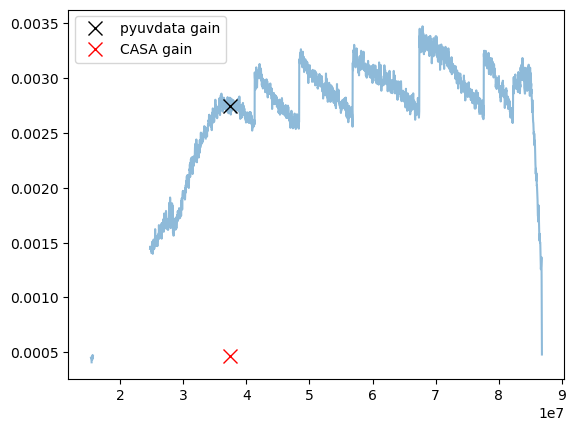

In [ ]:
# Plot the gains in the caltable and compare to the inferred value from the CASA-calibrated data and the pyuvdata-read value

single_ant_gains = data1[
    np.where(np.array(ant_ids1) == np.where(np.array(ant_names) == use_antenna_name)[0])[0]
]
plt.plot(
    frequencies.flatten(), np.abs(single_ant_gains[:, :, 0]).flatten(), alpha=0.5
)

plt.plot(
    use_freq,
    pyuvdata_gain,
    "x",
    markersize=10,
    color="black",
    label="pyuvdata gain"
)
plt.plot(use_freq, casa_gain, "x", markersize=10, color="red", label="CASA gain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain")
plt.legend()
plt.show()

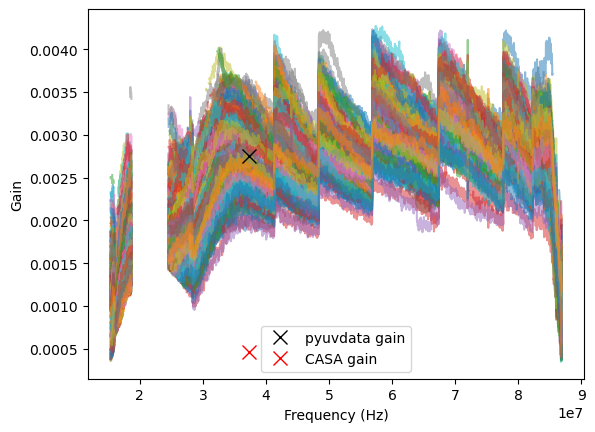

In [ ]:
# Could this be an antenna indexing issue? Now plot the gains for all antennas and compare to the inferred value from the CASA-calibrated data and the pyuvdata-read value

for ant_name in ant_names:
    single_ant_gains = data1[
        np.where(np.array(ant_ids1) == np.where(np.array(ant_names) == ant_name)[0])[0]
    ]
    plt.plot(frequencies.flatten(), np.abs(single_ant_gains[:, :, 0]).flatten(), alpha=0.5)

plt.plot(
    use_freq, pyuvdata_gain, "x", markersize=10, color="black", label="pyuvdata gain"
)
plt.plot(use_freq, casa_gain, "x", markersize=10, color="red", label="CASA gain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain")
plt.legend()
plt.show()

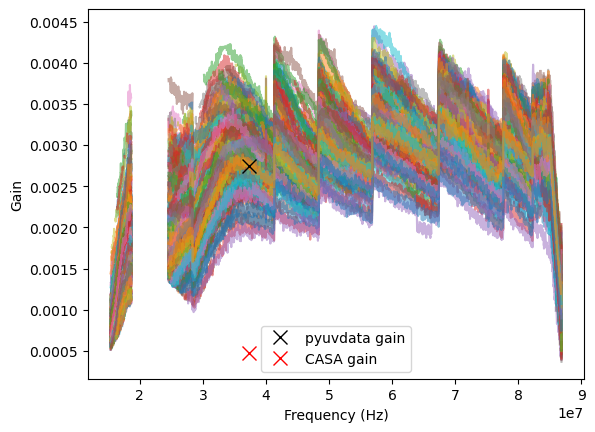

In [28]:
# What about a poloarization mismatch? Now plot the gains for all antennas for the other polarization and compare to the inferred value from the CASA-calibrated data and the pyuvdata-read value

use_pol = 1
for ant_name in ant_names:
    single_ant_gains = data1[
        np.where(np.array(ant_ids1) == np.where(np.array(ant_names) == ant_name)[0])[0]
    ]
    plt.plot(
        frequencies.flatten(),
        np.abs(single_ant_gains[:, :, use_pol]).flatten(),
        alpha=0.5,
    )

plt.plot(
    use_freq, pyuvdata_gain, "x", markersize=10, color="black", label="pyuvdata gain"
)
plt.plot(use_freq, casa_gain, "x", markersize=10, color="red", label="CASA gain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain")
plt.legend()
plt.show()